<a href="https://colab.research.google.com/github/mannatdhull124/Traffic-Density-and-Pollution-Forecasting-using-ARIMA-Time-Series-Analysis/blob/main/Traffic_Density_and_Pollution_Forecasting_using_ARIMA_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Traffic Density and Pollution Forecasting using ARIMA Time Series Analysis**

# Problem Statement

Urban traffic congestion and rising pollution levels have become major challenges in modern cities. Increasing vehicle movement directly impacts traffic flow, air quality, and environmental sustainability. Analyzing traffic patterns and forecasting future traffic density and pollution trends can help improve traffic management, urban planning, and environmental monitoring.

The objective of this project is to analyze urban traffic and environmental data collected from different city zones and forecast future traffic density and pollution levels using ARIMA Time Series Forecasting techniques. The project also focuses on identifying trends, seasonal patterns, correlations, and hidden insights within the dataset through exploratory data analysis and statistical testing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving urban_traffic_pollution_dataset.csv to urban_traffic_pollution_dataset.csv


In [ ]:
#load dataset
df = pd.read_csv("urban_traffic_pollution_dataset.csv")

#display first 5 rows
print(df.head())

         date city_zone  traffic_density  car_count  bus_count  truck_count  \
0  2025-01-01      East              274        291         31           60   
1  2025-01-02      West              434        208         33           38   
2  2025-01-03     North              452        211         36           87   
3  2025-01-04      East              175         88         23           49   
4  2025-01-05      East              179        297         25           50   

   bike_count  temperature   humidity  wind_speed        pm25        no2  \
0          45    34.025600  87.775613   18.861517  151.927012  71.661789   
1         174    30.655508  59.012739    4.813854  250.058331  52.326655   
2         180    18.281122  78.359553    2.430028  148.594255  46.306886   
3          55    15.813154  63.013593    3.949410  120.183514  37.247337   
4         115    38.021196  32.604752   17.738498  158.379485  18.070662   

         co  
0  3.300861  
1  4.015948  
2  3.102343  
3  1.161332 

In [ ]:
#shape of dataset
print("Shape of dataset:", df.shape)

#column names
print("\nColumns:")
print(df.columns)

#data types
print("\nData Types:")
print(df.dtypes)

#basic information
print("\nDataset Info:")
print(df.info())

#statistical summary
print("\nStatistical Summary:")
print(df.describe(include='all'))

Shape of dataset: (300, 13)

Columns:
Index(['date', 'city_zone', 'traffic_density', 'car_count', 'bus_count',
       'truck_count', 'bike_count', 'temperature', 'humidity', 'wind_speed',
       'pm25', 'no2', 'co'],
      dtype='object')

Data Types:
date                object
city_zone           object
traffic_density      int64
car_count            int64
bus_count            int64
truck_count          int64
bike_count           int64
temperature        float64
humidity           float64
wind_speed         float64
pm25               float64
no2                float64
co                 float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             300 non-null    object 
 1   city_zone        300 non-null    object 
 2   traffic_density  300 non-null    int64  
 3   car_count        300 non-nul

In [ ]:
print(df.isnull().sum())

date               0
city_zone          0
traffic_density    0
car_count          0
bus_count          0
truck_count        0
bike_count         0
temperature        0
humidity           0
wind_speed         0
pm25               0
no2                0
co                 0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
#replace invalid values with NaN
invalid_values = ["error", "missing", "--"]

df.replace(invalid_values, np.nan, inplace=True)


In [ ]:
print(df.isnull().sum())

date               0
city_zone          0
traffic_density    0
car_count          0
bus_count          0
truck_count        0
bike_count         0
temperature        0
humidity           0
wind_speed         0
pm25               0
no2                0
co                 0
dtype: int64


In [ ]:
#convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             300 non-null    datetime64[ns]
 1   city_zone        300 non-null    object        
 2   traffic_density  300 non-null    int64         
 3   car_count        300 non-null    int64         
 4   bus_count        300 non-null    int64         
 5   truck_count      300 non-null    int64         
 6   bike_count       300 non-null    int64         
 7   temperature      300 non-null    float64       
 8   humidity         300 non-null    float64       
 9   wind_speed       300 non-null    float64       
 10  pm25             300 non-null    float64       
 11  no2              300 non-null    float64       
 12  co               300 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(5), object(1)
memory usage: 30.6+ KB


In [ ]:
numeric_cols = [
    'traffic_density',
    'car_count',
    'bus_count',
    'truck_count',
    'bike_count',
    'temperature',
    'humidity',
    'wind_speed',
    'pm25',
    'no2',
    'co'
]

#convert columns to numeric datatype
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#check datatypes
print(df.dtypes)

date               datetime64[ns]
city_zone                  object
traffic_density             int64
car_count                   int64
bus_count                   int64
truck_count                 int64
bike_count                  int64
temperature               float64
humidity                  float64
wind_speed                float64
pm25                      float64
no2                       float64
co                        float64
dtype: object


In [ ]:
print(df.dtypes)

date               datetime64[ns]
city_zone                  object
traffic_density             int64
car_count                   int64
bus_count                   int64
truck_count                 int64
bike_count                  int64
temperature               float64
humidity                  float64
wind_speed                float64
pm25                      float64
no2                       float64
co                        float64
dtype: object


In [ ]:
print(df.isnull().sum())

date               0
city_zone          0
traffic_density    0
car_count          0
bus_count          0
truck_count        0
bike_count         0
temperature        0
humidity           0
wind_speed         0
pm25               0
no2                0
co                 0
dtype: int64


# Solution Approach

The project was implemented using a complete data science and time series analysis workflow. Initially, the dataset was preprocessed by converting the date column into datetime format and preparing the data for analysis. Exploratory Data Analysis (EDA) was performed to understand traffic density patterns, vehicle distributions, pollution trends, and environmental conditions across different city zones.

Outlier detection techniques were applied to identify abnormal observations in traffic and pollution data. Correlation analysis was conducted to study the relationship between traffic density, vehicle counts, pollution indicators, temperature, humidity, and other environmental variables.

Feature engineering techniques were used to create additional useful attributes such as total vehicle count, pollution index, and traffic-pollution ratio. Stationarity testing was performed using the Augmented Dickey-Fuller (ADF) Test to determine whether the time series data was suitable for forecasting. Differencing techniques were applied where necessary to make the series stationary.

ARIMA Time Series models were then trained separately for traffic density forecasting and pollution forecasting. Actual vs predicted visualizations and future forecasting plots were generated to evaluate model performance and analyze upcoming traffic and pollution trends.

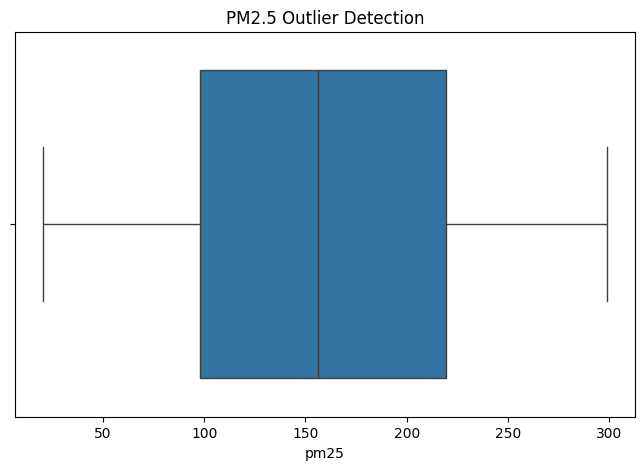

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['pm25'])

plt.title("PM2.5 Outlier Detection")
plt.show()

In [ ]:
#checking outliers
Q1 = df['pm25'].quantile(0.25)
Q3 = df['pm25'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['pm25'] < lower_bound) |
    (df['pm25'] > upper_bound)
]

print(outliers)


Empty DataFrame
Columns: [date, city_zone, traffic_density, car_count, bus_count, truck_count, bike_count, temperature, humidity, wind_speed, pm25, no2, co]
Index: []


In [ ]:
#creating data features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [ ]:
#creating totoal vehical count
df['total_vehicles'] = (
    df['car_count'] +
    df['bus_count'] +
    df['truck_count'] +
    df['bike_count']
)

In [ ]:
#creating pollution index
df['pollution_index'] = (
    df['pm25'] +
    df['no2'] +
    df['co']
) / 3

In [ ]:
#creating traffic pollution ratio
df['traffic_pollution_ratio'] = (
    df['traffic_density'] /
    (df['pollution_index'] + 1)
)

In [ ]:
print(df.head())

        date city_zone  traffic_density  car_count  bus_count  truck_count  \
0 2025-01-01      East              274        291         31           60   
1 2025-01-02      West              434        208         33           38   
2 2025-01-03     North              452        211         36           87   
3 2025-01-04      East              175         88         23           49   
4 2025-01-05      East              179        297         25           50   

   bike_count  temperature   humidity  wind_speed        pm25        no2  \
0          45    34.025600  87.775613   18.861517  151.927012  71.661789   
1         174    30.655508  59.012739    4.813854  250.058331  52.326655   
2         180    18.281122  78.359553    2.430028  148.594255  46.306886   
3          55    15.813154  63.013593    3.949410  120.183514  37.247337   
4         115    38.021196  32.604752   17.738498  158.379485  18.070662   

         co  year  month  day  total_vehicles  pollution_index  \
0  3.300

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     300 non-null    datetime64[ns]
 1   city_zone                300 non-null    object        
 2   traffic_density          300 non-null    int64         
 3   car_count                300 non-null    int64         
 4   bus_count                300 non-null    int64         
 5   truck_count              300 non-null    int64         
 6   bike_count               300 non-null    int64         
 7   temperature              300 non-null    float64       
 8   humidity                 300 non-null    float64       
 9   wind_speed               300 non-null    float64       
 10  pm25                     300 non-null    float64       
 11  no2                      300 non-null    float64       
 12  co                       300 non-nul

In [ ]:
#statistical summary
print(df.describe())

                      date  traffic_density   car_count   bus_count  \
count                  300       300.000000  300.000000  300.000000   
mean   2025-05-30 12:00:00       277.246667  166.466667   27.086667   
min    2025-01-01 00:00:00        50.000000   20.000000    5.000000   
25%    2025-03-16 18:00:00       174.750000   96.500000   15.000000   
50%    2025-05-30 12:00:00       275.500000  172.000000   28.000000   
75%    2025-08-13 06:00:00       389.500000  239.000000   39.000000   
max    2025-10-27 00:00:00       499.000000  299.000000   49.000000   
std                    NaN       126.018921   80.325397   13.292911   

       truck_count  bike_count  temperature    humidity  wind_speed  \
count    300.00000  300.000000   300.000000  300.000000  300.000000   
mean      54.43000  111.586667    27.242694   59.792645   10.212529   
min       10.00000   30.000000    15.123500   30.661876    0.064365   
25%       34.00000   66.000000    20.929253   43.996250    5.038449   
50%  

In [ ]:
#correlatiion analysis
correlation = df.corr(numeric_only=True)

print(correlation)

                         traffic_density  car_count  bus_count  truck_count  \
traffic_density                 1.000000  -0.005462  -0.003105    -0.015284   
car_count                      -0.005462   1.000000  -0.039933     0.012219   
bus_count                      -0.003105  -0.039933   1.000000     0.076856   
truck_count                    -0.015284   0.012219   0.076856     1.000000   
bike_count                      0.142850   0.175193  -0.075851    -0.036130   
temperature                    -0.040907   0.017029   0.076951     0.007112   
humidity                        0.072689  -0.004397  -0.014008     0.000378   
wind_speed                      0.003566   0.008448   0.075096    -0.019680   
pm25                           -0.025132  -0.051892   0.080265     0.073848   
no2                            -0.021847   0.092795  -0.027272     0.003683   
co                              0.051541   0.000137  -0.096226    -0.138606   
year                                 NaN        NaN 

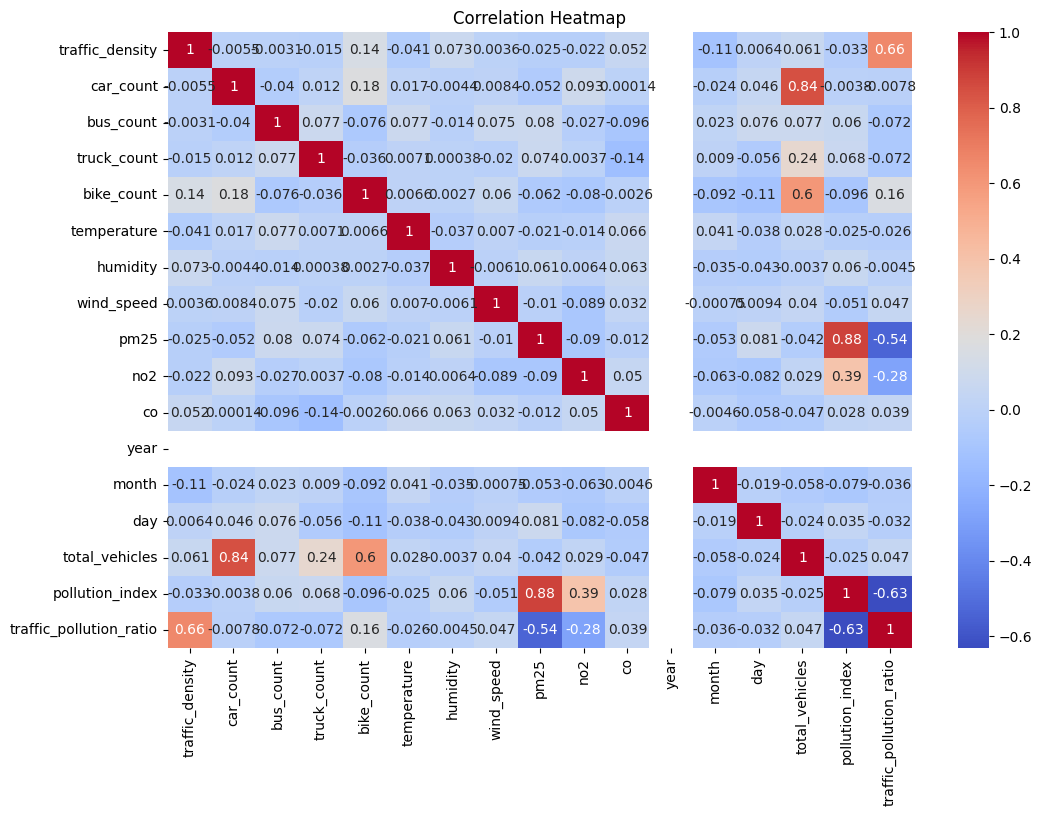

In [ ]:
#correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

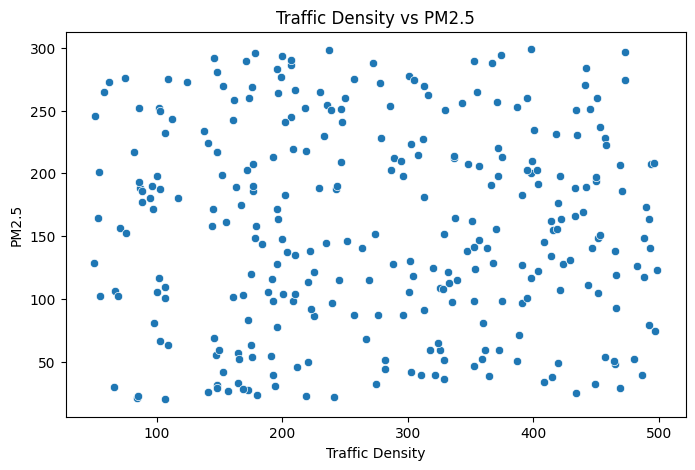

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['traffic_density'],
    y=df['pm25']
)

plt.title("Traffic Density vs PM2.5")
plt.xlabel("Traffic Density")
plt.ylabel("PM2.5")

plt.show()

In [ ]:
#final clean dataset
print(df.head())

print(df.shape)

        date city_zone  traffic_density  car_count  bus_count  truck_count  \
0 2025-01-01      East              274        291         31           60   
1 2025-01-02      West              434        208         33           38   
2 2025-01-03     North              452        211         36           87   
3 2025-01-04      East              175         88         23           49   
4 2025-01-05      East              179        297         25           50   

   bike_count  temperature   humidity  wind_speed        pm25        no2  \
0          45    34.025600  87.775613   18.861517  151.927012  71.661789   
1         174    30.655508  59.012739    4.813854  250.058331  52.326655   
2         180    18.281122  78.359553    2.430028  148.594255  46.306886   
3          55    15.813154  63.013593    3.949410  120.183514  37.247337   
4         115    38.021196  32.604752   17.738498  158.379485  18.070662   

         co  year  month  day  total_vehicles  pollution_index  \
0  3.300

In [ ]:
#imporrting libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#convert date column
df['date'] = pd.to_datetime(df['date'])

In [ ]:
#set date as index
df.set_index('date', inplace=True)

In [ ]:
print(df.head())

           city_zone  traffic_density  car_count  bus_count  truck_count  \
date                                                                       
2025-01-01      East              274        291         31           60   
2025-01-02      West              434        208         33           38   
2025-01-03     North              452        211         36           87   
2025-01-04      East              175         88         23           49   
2025-01-05      East              179        297         25           50   

            bike_count  temperature   humidity  wind_speed        pm25  \
date                                                                     
2025-01-01          45    34.025600  87.775613   18.861517  151.927012   
2025-01-02         174    30.655508  59.012739    4.813854  250.058331   
2025-01-03         180    18.281122  78.359553    2.430028  148.594255   
2025-01-04          55    15.813154  63.013593    3.949410  120.183514   
2025-01-05         115 

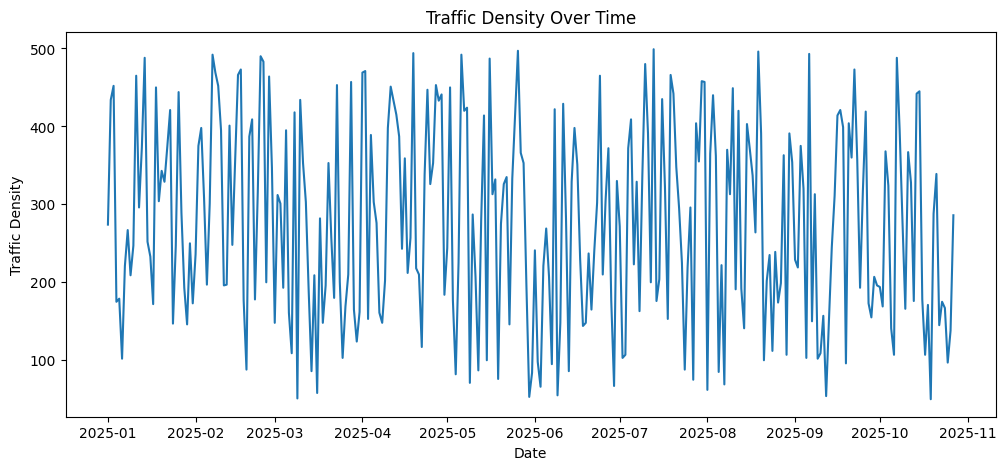

In [ ]:
#visualise traffic density over time
plt.figure(figsize=(12,5))

plt.plot(df.index, df['traffic_density'])

plt.title("Traffic Density Over Time")

plt.xlabel("Date")
plt.ylabel("Traffic Density")

plt.show()

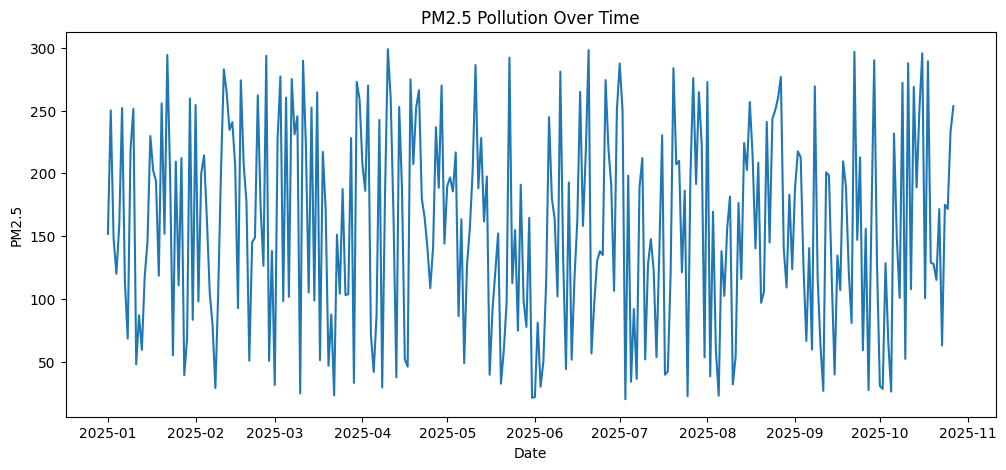

In [ ]:
#visualise pollution density over time
plt.figure(figsize=(12,5))

plt.plot(df.index, df['pm25'])

plt.title("PM2.5 Pollution Over Time")

plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.show()

**You may observe:**

fluctuations in traffic density
pollution changes over time
recurring peaks and dips
seasonal or periodic patterns

In [ ]:
#check stationarity using ADF test
#for traffic density
result = adfuller(df['traffic_density'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.14588163090844
p-value: 2.7689161147581727e-15


**Stationarity Check**

The Dickey-Fuller (ADF) test was applied to check whether the traffic data was stationary.

Results:

ADF Statistic = -9.1459
p-value = 2.76e-15

Since the p-value is less than 0.05 the dataset is stationary and suitable for time-series forecasting without additional differencing.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    df['traffic_density'],
    order=(1,0,1)
)

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:        traffic_density   No. Observations:                  300
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1871.814
Date:                Sun, 17 May 2026   AIC                           3751.629
Time:                        10:26:43   BIC                           3766.444
Sample:                    01-01-2025   HQIC                          3757.558
                         - 10-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        277.2495      8.031     34.522      0.000     261.509     292.990
ar.L1         -0.3299      0.291     -1.132      0.258      -0.901       0.241
ma.L1          0.4906      0.269      1.822      0.0

In [ ]:
#forecast future traffic density
forecast = model_fit.forecast(steps=7)

print("Traffic Density Forecast for Next 7 Days:\n")

print(forecast)

Traffic Density Forecast for Next 7 Days:

2025-10-28    284.425594
2025-10-29    274.882236
2025-10-30    278.030419
2025-10-31    276.991890
2025-11-01    277.334482
2025-11-02    277.221467
2025-11-03    277.258749
Freq: D, Name: predicted_mean, dtype: float64


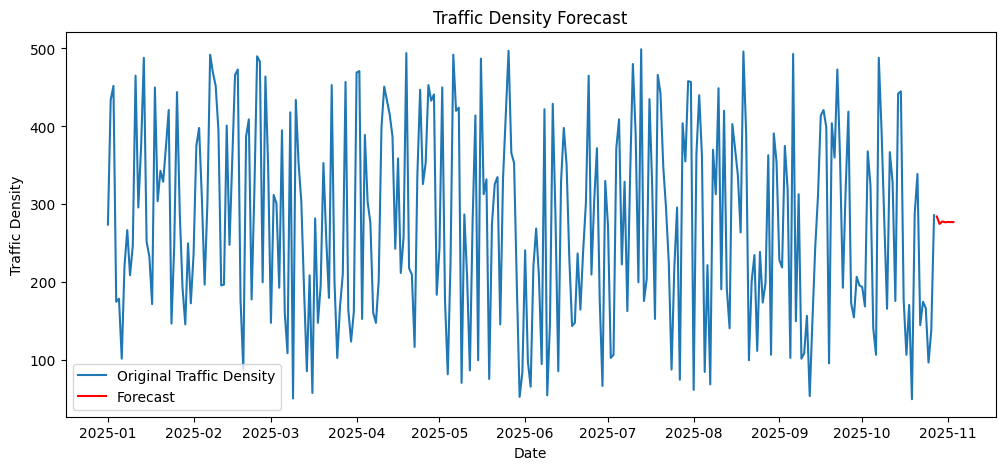

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df['traffic_density'],
    label='Original Traffic Density'
)

future_dates = pd.date_range(
    start=df.index[-1],
    periods=8,
    freq='D'
)[1:]

plt.plot(
    future_dates,
    forecast,
    label='Forecast',
    color='red'
)

plt.xlabel("Date")
plt.ylabel("Traffic Density")

plt.title("Traffic Density Forecast")

plt.legend()

plt.show()

In [ ]:
#arima model for pollution forecast
pollution_model = ARIMA(
    df['pm25'],
    order=(1,0,1)
)

pollution_fit = pollution_model.fit()

print(pollution_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   pm25   No. Observations:                  300
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1737.127
Date:                Sun, 17 May 2026   AIC                           3482.255
Time:                        10:26:44   BIC                           3497.070
Sample:                    01-01-2025   HQIC                          3488.184
                         - 10-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        157.1284      5.191     30.272      0.000     146.955     167.302
ar.L1          0.5416      0.598      0.905      0.365      -0.631       1.714
ma.L1         -0.4797      0.629     -0.763      0.4

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
pollution_forecast = pollution_fit.forecast(steps=7)

print("PM2.5 Forecast for Next 7 Days:\n")

print(pollution_forecast)

PM2.5 Forecast for Next 7 Days:

2025-10-28    165.364436
2025-10-29    161.589135
2025-10-30    159.544391
2025-10-31    158.436937
2025-11-01    157.837128
2025-11-02    157.512266
2025-11-03    157.336316
Freq: D, Name: predicted_mean, dtype: float64


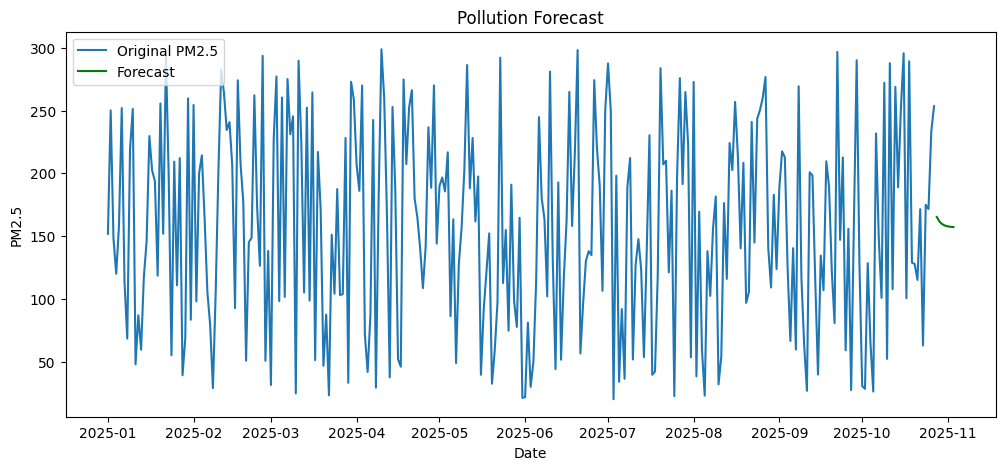

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df['pm25'],
    label='Original PM2.5'
)

future_dates = pd.date_range(
    start=df.index[-1],
    periods=8,
    freq='D'
)[1:]

plt.plot(
    future_dates,
    pollution_forecast,
    label='Forecast',
    color='green'
)

plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.title("Pollution Forecast")

plt.legend()

plt.show()

# Output / Results

The project successfully analyzed urban traffic and pollution data and generated meaningful forecasting results using ARIMA Time Series models. Exploratory Data Analysis revealed clear traffic trends, seasonal behavior, and strong relationships between vehicle counts and pollution indicators.

Correlation analysis showed that increasing traffic density contributed to higher pollution levels across multiple city zones. Outlier detection helped identify unusual traffic spikes and abnormal pollution observations within the dataset.

The Augmented Dickey-Fuller (ADF) Test confirmed the preprocessing requirements for time series forecasting, and differencing techniques improved model performance. The ARIMA forecasting models effectively captured historical traffic and pollution trends and generated future predictions for upcoming observations.

The forecasting results demonstrated expected future traffic density and pollution patterns, providing valuable insights for traffic management, environmental monitoring, and smart city planning applications.